In [264]:
%pip install emoji


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [309]:
import numpy as np
import pandas as pd
import tensorflow as tf
import emoji
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Input, Bidirectional, Dropout
from tensorflow.keras import regularizers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from nltk.stem import PorterStemmer
import keras_tuner as kt
from tensorflow.keras.optimizers import Adam, RMSprop

In [266]:

import tensorflow_datasets as tfds

In [267]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("lakshmi25npathi/imdb-dataset-of-50k-movie-reviews")

print("Path to dataset files:", path)

Path to dataset files: /home/heux/.cache/kagglehub/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews/versions/1


In [268]:
df= pd.read_csv("/home/heux/.cache/kagglehub/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews/versions/1/IMDB Dataset.csv")

In [269]:
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [270]:
df['review'] = df['review'].str.lower()
df['review'] = df['review'].str.replace('<[^<]+?>', '', regex=True)
df['review'] = df['review'].str.replace(r'http\S+|www\S+|https\S+', '', regex=True)


In [271]:
#remove punctuation and special characters
df['review'] = df['review'].str.replace('[^\w\s]', '', regex=True)

In [272]:
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize



stop_words = set(stopwords.words('english'))

def remove_stopwords(text):
    words = word_tokenize(text.lower())
    filtered_words = [word for word in words if word not in stop_words]
    return " ".join(filtered_words)

#df['review'] = df['review'].apply(remove_stopwords)

In [ ]:
#stemming

stemmer = PorterStemmer()



In [273]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(df['review'], df['sentiment'], test_size=0.2, random_state=42)

In [274]:
x_train.shape

(40000,)

In [275]:
tokenizer = Tokenizer(num_words=10000, oov_token="<OOV>")

In [276]:
tokenizer.fit_on_texts(x_train)

In [277]:
vocab_size = min(10000, len(tokenizer.word_index) + 1)

In [278]:
import numpy as np

word_counts = list(tokenizer.word_counts.values())

p95 = np.percentile(word_counts, 98)
print("95th percentile of word frequencies:", p95)

95th percentile of word frequencies: 171.0


In [279]:
from collections import Counter

word_counts = tokenizer.word_counts

print("Unique words:", len(word_counts))

# Top 20 most frequent words
print(Counter(word_counts).most_common(20))

Unique words: 193131
[('the', 520692), ('and', 255149), ('a', 254843), ('of', 230120), ('to', 212854), ('is', 168045), ('in', 146043), ('it', 121047), ('i', 116713), ('this', 116236), ('that', 108792), ('was', 76215), ('as', 72069), ('with', 68954), ('for', 68796), ('movie', 66594), ('but', 64223), ('film', 59652), ('on', 53021), ('not', 47736)]


In [280]:
x_train= tokenizer.texts_to_sequences(x_train)
x_test= tokenizer.texts_to_sequences(x_test)

In [281]:
max_len= max(len(x) for x in x_train)

In [282]:
x_train = pad_sequences(x_train, padding='post', maxlen=200)
x_test = pad_sequences(x_test, padding='post', maxlen=200)

In [283]:
y_train = np.array([1 if label == 'positive' else 0 for label in y_train])
y_test = np.array([1 if label == 'positive' else 0 for label in y_test])

In [299]:
model = Sequential()
model.add(Input(shape=(200,)))
model.add(Embedding(vocab_size, 64, mask_zero=True))
model.add(Bidirectional(LSTM(64, dropout=0.3)))  # 128 → 64
model.add(Dense(32, activation='relu', kernel_regularizer=regularizers.l2(0.001)))  # 64 → 32
model.add(Dropout(0.5))
model.add(Dense(1, activation='sigmoid', kernel_regularizer=regularizers.l2(0.001)))

In [300]:
model.summary()

Model: "sequential_21"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_21 (Embedding)        │ (None, 200, 64)        │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_20                │ (None, 128)            │        66,048 │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_18 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 710,209 (2.71 MB)

 Trainable params: 710,209 (2.71 MB)

 Non-trainable params: 0 (0.00 B)

In [301]:

model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

In [302]:
# -----------------------------
# 6. Train with explicit validation_data + callbacks
# -----------------------------
es = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
rlrop = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-5)

history = model.fit(
    x_train, y_train,
    validation_data=(x_test, y_test),
    epochs=70,
    batch_size=128,
    verbose=1,
    callbacks=[es, rlrop]
)

Epoch 1/70
313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 21ms/step - accuracy: 0.7805 - loss: 0.4645 - val_accuracy: 0.8784 - val_loss: 0.3022 - learning_rate: 0.0010
Epoch 2/70
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - accuracy: 0.8996 - loss: 0.2785 - val_accuracy: 0.8898 - val_loss: 0.2798 - learning_rate: 0.0010
Epoch 3/70
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - accuracy: 0.9172 - loss: 0.2335 - val_accuracy: 0.8881 - val_loss: 0.2874 - learning_rate: 0.0010
Epoch 4/70
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 21ms/step - accuracy: 0.9322 - loss: 0.1997 - val_accuracy: 0.8764 - val_loss: 0.3205 - learning_rate: 0.0010
Epoch 5/70
298/313 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.9475 - loss: 0.1632

KeyboardInterrupt: 

In [ ]:
model.save("lstm_model3.keras")

In [322]:
def build_model(hp):

    model = Sequential()

    model.add(Input(shape=(200,)))

    model.add(
        Embedding(
            input_dim=vocab_size,
            output_dim=hp.Choice(
                "embedding_dim",
                [64,100]
            ),
            mask_zero=True
        )
    )

    num_layers = hp.Int("num_lstm_layers", 1, 2)

    for i in range(num_layers):

        model.add(
            Bidirectional(
                LSTM(
                    units=hp.Int(
                        f"lstm_units_{i}",
                        64,
                        256,
                        step=64
                    ),
                    return_sequences=(i < num_layers-1)
                )
            )
        )

        model.add(
            Dropout(
                hp.Float(
                    f"dropout_{i}",
                    0.2,
                    0.5,
                    step=0.1
                )
            )
        )

    model.add(Dense(1, activation="sigmoid"))

    lr = hp.Choice(
        "learning_rate",
        [1e-2,1e-3,5e-4,1e-4]
    )

    opt = hp.Choice(
        "optimizer",
        ["adam","rmsprop"]
    )

    if opt == "adam":
        optimizer = Adam(learning_rate=lr)
    else:
        optimizer = RMSprop(learning_rate=lr)

    model.compile(
        optimizer=optimizer,
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [325]:
tuner = kt.Hyperband(
    build_model,
    objective="val_accuracy",
    max_epochs=20,
    factor=3,
    directory="tuning2",
    project_name="sa2"
)

In [326]:
tuner.search(
    x_train, y_train,
    epochs=20,
    validation_data=(x_test, y_test),
    batch_size=64,
    callbacks=[es, rlrop]
)

Trial 30 Complete [00h 02m 36s]
val_accuracy: 0.8907999992370605

Best val_accuracy So Far: 0.9013000130653381
Total elapsed time: 00h 54m 30s


In [327]:
best_model = tuner.get_best_models(num_models=1)[0]

/home/heux/anaconda3/envs/tf_gpu/lib/python3.10/site-packages/keras/src/saving/saving_lib.py:794: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 2 variables whereas the saved optimizer has 17 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [328]:
best_model.save("best_imdb_bilstm.keras")

In [329]:
%pip install pickel

ERROR: Could not find a version that satisfies the requirement pickel (from versions: none)

[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
ERROR: No matching distribution found for pickel
Note: you may need to restart the kernel to use updated packages.


In [330]:
import pickle
# save
pickle.dump(tokenizer, open("tokenizer.pickle", "wb"))

In [332]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

# probabilities from the model
y_prob = best_model.predict(x_test)   # or model.predict(x_test)

# convert probabilities to class labels
y_pred = (y_prob >= 0.5).astype(int).ravel()

# true labels should already be 0/1
y_true = y_test.ravel()

# confusion matrix
cm = confusion_matrix(y_true, y_pred)
print("Confusion Matrix:")
print(cm)

# classification report
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=["negative", "positive"]))

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step
Confusion Matrix:
[[4474  487]
 [ 500 4539]]

Classification Report:
              precision    recall  f1-score   support

    negative       0.90      0.90      0.90      4961
    positive       0.90      0.90      0.90      5039

    accuracy                           0.90     10000
   macro avg       0.90      0.90      0.90     10000
weighted avg       0.90      0.90      0.90     10000



In [333]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

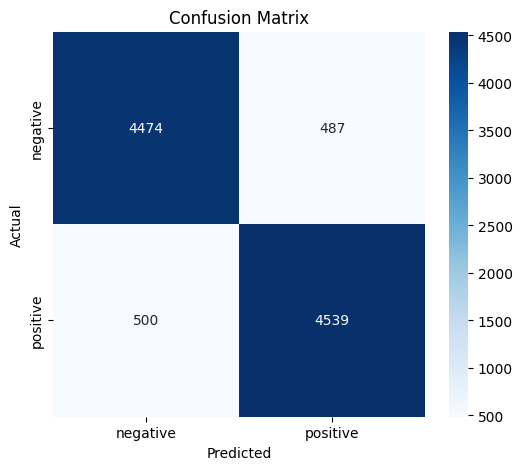

In [334]:
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['negative', 'positive'],
            yticklabels=['negative', 'positive'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()